# Thermal Cold-Region Dataset Deep Audit Notebook

Purpose: **understand the dataset before running more experiments**.

This notebook generates audit CSVs and slide-ready visualizations:

1. `01_file_inventory.csv`
2. `02_image_mask_pairing_check.csv`
3. `03_patient_subject_case_doctor_try_table.csv`
4. `04_duplicate_image_check.csv`
5. `05_mask_label_value_check.csv`
6. `06_mask_pixel_statistics.csv`
7. `07_doctor_agreement_table.csv`
8. `08_same_image_12_mask_visualization.png`
9. `09_problem_cases.csv`

It also saves additional figures for slides: doctor variability, try variability, pixel-count plots, and problem-case examples.

In [13]:
# ============================================================
# SECTION 00 — CONFIG
# ============================================================

from pathlib import Path

ROOT = Path("/media/data/rPPG/rPPG_Data/SHARE/PixelLabelData")
IMG_DIR = ROOT / "FIR_input"
MASK_DIR = ROOT / "PixelLabelData"

OUT_DIR = Path("THERMO_DATASET_AUDIT")
CSV_DIR = OUT_DIR / "csv"
FIG_DIR = OUT_DIR / "figures"
CACHE_DIR = OUT_DIR / "cache"

CSV_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = [".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"]
MASK_EXTS = [".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"]

# Project label convention used so far:
# 0/1 = background, 2 = abdomen/body, 3 = cold region
BODY_REGION_VALUES = [2, 3]
COLD_REGION_VALUES = [3]

# If filenames do not contain doctor/try information, natural ordering can assign them.
EXPECTED_DOCTORS = ["A", "B", "C", "D"]
EXPECTED_TRIES_PER_DOCTOR = 3
EXPECTED_ANNOTATIONS_PER_IMAGE = len(EXPECTED_DOCTORS) * EXPECTED_TRIES_PER_DOCTOR

# Pairing mode:
# "auto" supports:
#   - same number of images and masks: image[i] ↔ mask[i]
#   - masks = images × 12: image[i] ↔ 12 masks
# Then exact duplicate image hashes are used to identify repeated same-image annotations.
PAIRING_MODE = "auto"

RANDOM_SEED = 42

print("IMG_DIR:", IMG_DIR)
print("MASK_DIR:", MASK_DIR)
print("OUT_DIR:", OUT_DIR.resolve())

IMG_DIR: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/FIR_input
MASK_DIR: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/PixelLabelData
OUT_DIR: /home/rafsan/Documents/GitHub/Cool_GANs/THERMO_DATASET_AUDIT


In [14]:
# ============================================================
# SECTION 01 — IMPORTS + HELPERS
# ============================================================

import os
import re
import json
import math
import hashlib
import random
import itertools
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

try:
    from scipy import ndimage as ndi
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


def natural_key(s):
    s = str(s)
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", s)]


def list_files(folder, exts):
    folder = Path(folder)
    files = []
    for ext in exts:
        files.extend(folder.rglob(f"*{ext}"))
        files.extend(folder.rglob(f"*{ext.upper()}"))
    return sorted(set(files), key=lambda p: natural_key(p.name))


def file_md5(path, chunk_size=1_048_576):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()


def load_gray(path):
    img = Image.open(path)
    arr = np.array(img)
    if arr.ndim == 3:
        arr = arr[..., 0]
    return arr


def read_image_info(path, role):
    path = Path(path)
    info = {
        "role": role,
        "path": str(path),
        "name": path.name,
        "stem": path.stem,
        "suffix": path.suffix.lower(),
        "size_bytes": path.stat().st_size if path.exists() else np.nan,
        "md5": None,
        "width": np.nan,
        "height": np.nan,
        "mode": None,
        "dtype": None,
        "min_value": np.nan,
        "max_value": np.nan,
        "unique_values": "",
        "n_unique": np.nan,
    }
    try:
        info["md5"] = file_md5(path)
        im = Image.open(path)
        info["width"], info["height"] = im.size
        info["mode"] = im.mode
        arr = np.array(im)
        info["dtype"] = str(arr.dtype)
        info["min_value"] = float(np.nanmin(arr))
        info["max_value"] = float(np.nanmax(arr))
        if role == "mask":
            if arr.ndim == 3:
                arr = arr[..., 0]
            vals = np.unique(arr)
            info["unique_values"] = ",".join(map(str, vals.tolist()[:50]))
            info["n_unique"] = int(len(vals))
    except Exception as e:
        info["error"] = str(e)
    return info


def parse_subject_case_from_name(name):
    stem = Path(str(name)).stem
    s = stem
    out = {
        "subject_id": "UNK",
        "case_block": "UNK",
        "case_try_from_name": np.nan,
        "parsed_case_id": stem,
    }

    m = re.search(r"(S\d+)[-_ ]*([A-Za-z])?[-_ ]*(\d+)?", s, flags=re.IGNORECASE)
    if m:
        out["subject_id"] = m.group(1).upper()
        if m.group(2):
            out["case_block"] = m.group(2).upper()
        if m.group(3):
            out["case_try_from_name"] = int(m.group(3))
        parts = [out["subject_id"]]
        if out["case_block"] != "UNK":
            parts.append(out["case_block"])
        if not pd.isna(out["case_try_from_name"]):
            parts.append(str(int(out["case_try_from_name"])))
        out["parsed_case_id"] = "-".join(parts)
    return out


def parse_doctor_try_from_name(name):
    stem = Path(str(name)).stem
    s = stem.replace("_", "-").replace(" ", "-")
    out = {
        "doctor_id_parsed": "UNK",
        "annotation_try_parsed": np.nan,
        "doctor_parse_confidence": "none",
    }

    patterns = [
        r"(?:doctor|doc|dr|km|kmdoctor)[-_ ]*([A-D]|\d+)",
        r"(?:annotator|ann|rater)[-_ ]*([A-D]|\d+)",
        r"(?:^|[-_ ])D([1-4])(?:$|[-_ ])",
    ]
    for pat in patterns:
        m = re.search(pat, s, flags=re.IGNORECASE)
        if m:
            v = m.group(1).upper()
            if v.isdigit():
                idx = int(v) - 1
                v = EXPECTED_DOCTORS[idx] if 0 <= idx < len(EXPECTED_DOCTORS) else f"D{v}"
            out["doctor_id_parsed"] = v
            out["doctor_parse_confidence"] = "filename"
            break

    try_patterns = [
        r"(?:try|trial|repeat|rep|annotation)[-_ ]*(\d+)",
        r"(?:^|[-_ ])T(\d+)(?:$|[-_ ])",
    ]
    for pat in try_patterns:
        m = re.search(pat, s, flags=re.IGNORECASE)
        if m:
            out["annotation_try_parsed"] = int(m.group(1))
            break

    return out


def assign_doctor_try_by_index(annotation_index):
    doctor_idx = annotation_index // EXPECTED_TRIES_PER_DOCTOR
    try_idx = annotation_index % EXPECTED_TRIES_PER_DOCTOR
    doctor = EXPECTED_DOCTORS[doctor_idx] if doctor_idx < len(EXPECTED_DOCTORS) else f"D{doctor_idx+1}"
    return doctor, try_idx + 1


def mask_to_body_cold(mask):
    body = np.isin(mask, BODY_REGION_VALUES)
    cold = np.isin(mask, COLD_REGION_VALUES)
    return body, cold


def dice_bool(a, b, eps=1e-8):
    a = a.astype(bool)
    b = b.astype(bool)
    inter = np.logical_and(a, b).sum()
    denom = a.sum() + b.sum()
    if denom == 0:
        return 1.0
    return float((2 * inter + eps) / (denom + eps))


def iou_bool(a, b, eps=1e-8):
    a = a.astype(bool)
    b = b.astype(bool)
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    if union == 0:
        return 1.0
    return float((inter + eps) / (union + eps))


def normalize01(arr):
    arr = arr.astype(np.float32)
    lo, hi = np.nanpercentile(arr, [1, 99])
    if hi <= lo:
        lo, hi = np.nanmin(arr), np.nanmax(arr)
    return np.clip((arr - lo) / (hi - lo + 1e-8), 0, 1)


def make_overlay(gray, mask, color=(1.0, 0.0, 0.0), alpha=0.45):
    g = normalize01(gray)
    rgb = np.stack([g, g, g], axis=-1)
    mask = mask.astype(bool)
    col = np.array(color, dtype=np.float32)
    rgb[mask] = (1 - alpha) * rgb[mask] + alpha * col
    return np.clip(rgb, 0, 1)


def error_rgb(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    tp = pred & gt
    fp = pred & (~gt)
    fn = (~pred) & gt
    rgb = np.zeros((*gt.shape, 3), dtype=np.float32)
    rgb[tp] = [0, 1, 0]
    rgb[fp] = [1, 0, 0]
    rgb[fn] = [0, 0.25, 1]
    return rgb

print("Helpers loaded")

Helpers loaded


In [15]:
# ============================================================
# SECTION 02 — FILE INVENTORY
# Output: 01_file_inventory.csv
# ============================================================

image_paths = list_files(IMG_DIR, IMAGE_EXTS)
mask_paths = list_files(MASK_DIR, MASK_EXTS)

print("Found images:", len(image_paths))
print("Found masks:", len(mask_paths))

inventory_rows = []
for p in image_paths:
    inventory_rows.append(read_image_info(p, role="image"))
for p in mask_paths:
    inventory_rows.append(read_image_info(p, role="mask"))

inventory_df = pd.DataFrame(inventory_rows)
inventory_df.to_csv(CSV_DIR / "01_file_inventory.csv", index=False)

display(inventory_df.groupby("role").agg(n_files=("path", "count"), n_unique_md5=("md5", "nunique")))
display(inventory_df.head())
print("Saved:", CSV_DIR / "01_file_inventory.csv")

Found images: 79
Found masks: 79


,n_files,n_unique_md5
role,,
image,79,79
mask,79,79


,role,path,name,stem,suffix,size_bytes,md5,width,height,mode,dtype,min_value,max_value,unique_values,n_unique
0,image,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-B-2.bmp,S05-B-2,.bmp,245814,2d2d4f1f46406fd2fc03cfcef2960b2a,320,256,RGB,uint8,0.0,254.0,,NaN
1,image,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-B-3.bmp,S05-B-3,.bmp,245814,2d2ae48e7ebbed48a58adbc32f15c69e,320,256,RGB,uint8,0.0,254.0,,NaN
2,image,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-C-1.bmp,S05-C-1,.bmp,245814,b8e49e2cc2bbd32351f3315863c0293b,320,256,RGB,uint8,0.0,254.0,,NaN
3,image,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-C-2.bmp,S05-C-2,.bmp,245814,6a96be85a30104382550963cec2739fb,320,256,RGB,uint8,0.0,254.0,,NaN
4,image,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-C-3.bmp,S05-C-3,.bmp,245814,8fc7f548c6dfcb177a6f8643605108ce,320,256,RGB,uint8,0.0,254.0,,NaN


Saved: THERMO_DATASET_AUDIT/csv/01_file_inventory.csv


In [16]:
# ============================================================
# SECTION 03 — DUPLICATE IMAGE CHECK
# Output: 04_duplicate_image_check.csv
# ============================================================

img_inv = inventory_df[inventory_df["role"] == "image"].copy()
mask_inv = inventory_df[inventory_df["role"] == "mask"].copy()

img_inv["duplicate_image_count"] = img_inv.groupby("md5")["md5"].transform("count")
img_inv["image_duplicate_group"] = img_inv.groupby("md5", sort=False).ngroup().apply(lambda x: f"imgdup_{x:03d}")
img_inv.loc[img_inv["duplicate_image_count"] <= 1, "image_duplicate_group"] = "unique"

mask_inv["duplicate_mask_count"] = mask_inv.groupby("md5")["md5"].transform("count")
mask_inv["mask_duplicate_group"] = mask_inv.groupby("md5", sort=False).ngroup().apply(lambda x: f"maskdup_{x:03d}")
mask_inv.loc[mask_inv["duplicate_mask_count"] <= 1, "mask_duplicate_group"] = "unique"

dup_img_df = img_inv[
    ["path", "name", "stem", "md5", "width", "height", "duplicate_image_count", "image_duplicate_group"]
].copy()

dup_mask_df = mask_inv[
    ["path", "name", "stem", "md5", "width", "height", "duplicate_mask_count", "mask_duplicate_group"]
].copy()

duplicate_report = pd.concat([
    dup_img_df.assign(role="image"),
    dup_mask_df.assign(role="mask")
], ignore_index=True)

duplicate_report.to_csv(CSV_DIR / "04_duplicate_image_check.csv", index=False)

print("Image duplicate groups > 1:")
display(
    img_inv[img_inv["duplicate_image_count"] > 1]
    .sort_values(["image_duplicate_group", "name"])
    [["image_duplicate_group", "duplicate_image_count", "name", "path"]]
    .head(100)
)

print("Mask duplicate groups > 1:")
display(
    mask_inv[mask_inv["duplicate_mask_count"] > 1]
    .sort_values(["mask_duplicate_group", "name"])
    [["mask_duplicate_group", "duplicate_mask_count", "name", "path"]]
    .head(100)
)

print("Saved:", CSV_DIR / "04_duplicate_image_check.csv")

Image duplicate groups > 1:


,image_duplicate_group,duplicate_image_count,name,path


Mask duplicate groups > 1:


,mask_duplicate_group,duplicate_mask_count,name,path


Saved: THERMO_DATASET_AUDIT/csv/04_duplicate_image_check.csv


In [17]:
# ============================================================
# SECTION 04 — IMAGE ↔ MASK PAIRING AUDIT
# Outputs:
#   02_image_mask_pairing_check.csv
#   03_patient_subject_case_doctor_try_table.csv
# ============================================================

image_paths = sorted(image_paths, key=lambda p: natural_key(p.name))
mask_paths = sorted(mask_paths, key=lambda p: natural_key(p.name))

pair_rows = []

if PAIRING_MODE == "auto":
    if len(image_paths) == len(mask_paths):
        mode_used = "same_count_natural_order"
        for i, (img_p, mask_p) in enumerate(zip(image_paths, mask_paths)):
            img_info = read_image_info(img_p, "image")
            mask_info = read_image_info(mask_p, "mask")
            parsed = parse_subject_case_from_name(img_p.name)
            doc_try = parse_doctor_try_from_name(mask_p.name)

            # If the same image is duplicated 12 times, assign doctor/try within each duplicate image group later.
            pair_rows.append({
                "pair_index": i,
                "pairing_mode": mode_used,
                "case_id_raw": img_p.stem,
                **parsed,
                "image_path": str(img_p),
                "image_name": img_p.name,
                "image_md5": img_info["md5"],
                "image_width": img_info["width"],
                "image_height": img_info["height"],
                "mask_path": str(mask_p),
                "mask_name": mask_p.name,
                "mask_md5": mask_info["md5"],
                "mask_width": mask_info["width"],
                "mask_height": mask_info["height"],
                **doc_try,
                "annotation_index_initial": np.nan,
            })

    elif len(image_paths) > 0 and len(mask_paths) % len(image_paths) == 0:
        masks_per_image = len(mask_paths) // len(image_paths)
        mode_used = f"masks_per_image_natural_order_{masks_per_image}"
        for i, img_p in enumerate(image_paths):
            img_info = read_image_info(img_p, "image")
            parsed = parse_subject_case_from_name(img_p.name)
            for j in range(masks_per_image):
                mask_p = mask_paths[i * masks_per_image + j]
                mask_info = read_image_info(mask_p, "mask")
                doc_try = parse_doctor_try_from_name(mask_p.name)
                pair_rows.append({
                    "pair_index": len(pair_rows),
                    "pairing_mode": mode_used,
                    "case_id_raw": img_p.stem,
                    **parsed,
                    "image_path": str(img_p),
                    "image_name": img_p.name,
                    "image_md5": img_info["md5"],
                    "image_width": img_info["width"],
                    "image_height": img_info["height"],
                    "mask_path": str(mask_p),
                    "mask_name": mask_p.name,
                    "mask_md5": mask_info["md5"],
                    "mask_width": mask_info["width"],
                    "mask_height": mask_info["height"],
                    **doc_try,
                    "annotation_index_initial": j,
                })
    else:
        raise ValueError(f"Cannot auto-pair safely: {len(image_paths)} images, {len(mask_paths)} masks")
else:
    raise ValueError("Only PAIRING_MODE='auto' is implemented in this audit notebook.")

pair_df = pd.DataFrame(pair_rows)

# Assign duplicate-image group based on exact image content.
pair_df["n_files_with_same_image_md5"] = pair_df.groupby("image_md5")["image_md5"].transform("count")
pair_df["same_image_group"] = pair_df.groupby("image_md5", sort=False).ngroup().apply(lambda x: f"sameimg_{x:04d}")
pair_df.loc[pair_df["n_files_with_same_image_md5"] <= 1, "same_image_group"] = pair_df.loc[pair_df["n_files_with_same_image_md5"] <= 1, "case_id_raw"]

# One audit case = same image content. This is important when the same thermal image is repeated 12 times.
pair_df["audit_case_id"] = pair_df["same_image_group"]

# ============================================================
# FIX — SAFE NATURAL SORTING FOR AUDIT CASE TABLE
# ============================================================

def natural_sort_string(x):
    x = str(x)
    parts = re.split(r"(\d+)", x)
    out = []
    for p in parts:
        if p.isdigit():
            out.append(p.zfill(8))
        else:
            out.append(p.lower())
    return "_".join(out)

def safe_string_id(x):
    if isinstance(x, (list, tuple)):
        return "_".join(map(str, x))
    return str(x)

pair_df["audit_case_id"] = pair_df["same_image_group"].apply(safe_string_id)

pair_df["_audit_sort"] = pair_df["audit_case_id"].apply(natural_sort_string)
pair_df["_image_sort"] = pair_df["image_name"].apply(natural_sort_string)
pair_df["_mask_sort"] = pair_df["mask_name"].apply(natural_sort_string)

pair_df = (
    pair_df
    .sort_values(["_audit_sort", "_image_sort", "_mask_sort"])
    .drop(columns=["_audit_sort", "_image_sort", "_mask_sort"])
    .reset_index(drop=True)
)

pair_df["annotation_index"] = pair_df.groupby("audit_case_id").cumcount()
pair_df["n_annotations_for_same_image"] = pair_df.groupby("audit_case_id")["mask_path"].transform("count")

# Fill doctor/try if not parsed from filename.
doctors_final = []
tries_final = []
sources = []
for _, r in pair_df.iterrows():
    if r["doctor_id_parsed"] != "UNK":
        doctors_final.append(r["doctor_id_parsed"])
        if pd.isna(r["annotation_try_parsed"]):
            tries_final.append(int(r["annotation_index"] % EXPECTED_TRIES_PER_DOCTOR) + 1)
            sources.append("doctor_filename_try_assigned")
        else:
            tries_final.append(int(r["annotation_try_parsed"]))
            sources.append("filename")
    else:
        d, t = assign_doctor_try_by_index(int(r["annotation_index"]))
        doctors_final.append(d)
        tries_final.append(t)
        sources.append("assigned_by_order")

pair_df["doctor_id"] = doctors_final
pair_df["doctor_try"] = tries_final
pair_df["doctor_try_source"] = sources

pair_df["size_match"] = (pair_df["image_width"] == pair_df["mask_width"]) & (pair_df["image_height"] == pair_df["mask_height"])
pair_df["expected_12_annotations"] = pair_df["n_annotations_for_same_image"] == EXPECTED_ANNOTATIONS_PER_IMAGE

pair_df.to_csv(CSV_DIR / "02_image_mask_pairing_check.csv", index=False)

case_table = (
    pair_df.groupby(["audit_case_id", "subject_id", "parsed_case_id"])
    .agg(
        n_image_files=("image_path", "nunique"),
        n_mask_files=("mask_path", "nunique"),
        n_annotations=("mask_path", "count"),
        doctors=("doctor_id", lambda x: ",".join(sorted(set(map(str, x))))),
        tries=("doctor_try", lambda x: ",".join(map(str, sorted(set(map(int, x)))))),
        same_image_files=("image_name", lambda x: " | ".join(list(map(str, x))[:12])),
        mask_files=("mask_name", lambda x: " | ".join(list(map(str, x))[:12])),
        all_size_match=("size_match", "all"),
        expected_12_annotations=("expected_12_annotations", "first"),
        doctor_try_source=("doctor_try_source", lambda x: ",".join(sorted(set(map(str, x))))),
    )
    .reset_index()
)

case_table.to_csv(CSV_DIR / "03_patient_subject_case_doctor_try_table.csv", index=False)

print("Pairing mode used:", mode_used)
print("Total pair rows:", len(pair_df))
print("Audit cases / same-image groups:", pair_df["audit_case_id"].nunique())
print("Cases with 12 annotations:", int(case_table["expected_12_annotations"].sum()), "/", len(case_table))

display(case_table.head(20))
print("Saved:", CSV_DIR / "02_image_mask_pairing_check.csv")
print("Saved:", CSV_DIR / "03_patient_subject_case_doctor_try_table.csv")

Pairing mode used: same_count_natural_order
Total pair rows: 79
Audit cases / same-image groups: 79
Cases with 12 annotations: 0 / 79


,audit_case_id,subject_id,parsed_case_id,n_image_files,n_mask_files,n_annotations,doctors,tries,same_image_files,mask_files,all_size_match,expected_12_annotations,doctor_try_source
0,S05-B-2,S05,S05-B-2,1,1,1,A,1,S05-B-2.bmp,Label_1.png,True,False,assigned_by_order
1,S05-B-3,S05,S05-B-3,1,1,1,A,1,S05-B-3.bmp,Label_2.png,True,False,assigned_by_order
2,S05-C-1,S05,S05-C-1,1,1,1,A,1,S05-C-1.bmp,Label_3.png,True,False,assigned_by_order
3,S05-C-2,S05,S05-C-2,1,1,1,A,1,S05-C-2.bmp,Label_4.png,True,False,assigned_by_order
4,S05-C-3,S05,S05-C-3,1,1,1,A,1,S05-C-3.bmp,Label_5.png,True,False,assigned_by_order
5,S05-D-1,S05,S05-D-1,1,1,1,A,1,S05-D-1.bmp,Label_6.png,True,False,assigned_by_order
6,S05-D-2,S05,S05-D-2,1,1,1,A,1,S05-D-2.bmp,Label_7.png,True,False,assigned_by_order
7,S05-D-3,S05,S05-D-3,1,1,1,A,1,S05-D-3.bmp,Label_8.png,True,False,assigned_by_order
8,S06-A-1,S06,S06-A-1,1,1,1,A,1,S06-A-1.bmp,Label_9.png,True,False,assigned_by_order
9,S06-A-2,S06,S06-A-2,1,1,1,A,1,S06-A-2.bmp,Label_10.png,True,False,assigned_by_order


Saved: THERMO_DATASET_AUDIT/csv/02_image_mask_pairing_check.csv
Saved: THERMO_DATASET_AUDIT/csv/03_patient_subject_case_doctor_try_table.csv


In [18]:
# ============================================================
# SECTION 05 — MASK LABEL VALUE + PIXEL STATISTICS
# Outputs:
#   05_mask_label_value_check.csv
#   06_mask_pixel_statistics.csv
# ============================================================

label_rows = []
pixel_rows = []

for _, r in pair_df.iterrows():
    mask = load_gray(r["mask_path"])
    vals, counts = np.unique(mask, return_counts=True)
    val_count_dict = {int(v): int(c) for v, c in zip(vals, counts)}

    body, cold = mask_to_body_cold(mask)

    h, w = mask.shape[:2]
    total = h * w

    if body.any():
        ys, xs = np.where(body)
        body_bbox = [int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())]
    else:
        body_bbox = [np.nan, np.nan, np.nan, np.nan]

    if cold.any():
        ys, xs = np.where(cold)
        cold_bbox = [int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())]
    else:
        cold_bbox = [np.nan, np.nan, np.nan, np.nan]

    label_rows.append({
        "audit_case_id": r["audit_case_id"],
        "subject_id": r["subject_id"],
        "parsed_case_id": r["parsed_case_id"],
        "doctor_id": r["doctor_id"],
        "doctor_try": r["doctor_try"],
        "mask_name": r["mask_name"],
        "mask_path": r["mask_path"],
        "unique_values": ",".join(map(str, vals.tolist())),
        "n_unique": int(len(vals)),
        "value_counts_json": json.dumps(val_count_dict),
        "has_expected_cold_label": int(any(v in COLD_REGION_VALUES for v in vals)),
        "has_expected_body_label": int(any(v in BODY_REGION_VALUES for v in vals)),
    })

    pixel_rows.append({
        "audit_case_id": r["audit_case_id"],
        "subject_id": r["subject_id"],
        "parsed_case_id": r["parsed_case_id"],
        "doctor_id": r["doctor_id"],
        "doctor_try": r["doctor_try"],
        "image_name": r["image_name"],
        "mask_name": r["mask_name"],
        "image_path": r["image_path"],
        "mask_path": r["mask_path"],
        "height": int(h),
        "width": int(w),
        "total_pixels": int(total),
        "body_pixels": int(body.sum()),
        "cold_pixels": int(cold.sum()),
        "body_fraction_image": float(body.mean()),
        "cold_fraction_image": float(cold.mean()),
        "cold_fraction_in_body": float(cold.sum() / (body.sum() + 1e-8)),
        "body_bbox_x1": body_bbox[0],
        "body_bbox_y1": body_bbox[1],
        "body_bbox_x2": body_bbox[2],
        "body_bbox_y2": body_bbox[3],
        "cold_bbox_x1": cold_bbox[0],
        "cold_bbox_y1": cold_bbox[1],
        "cold_bbox_x2": cold_bbox[2],
        "cold_bbox_y2": cold_bbox[3],
        "empty_body": int(body.sum() == 0),
        "empty_cold": int(cold.sum() == 0),
    })

label_df = pd.DataFrame(label_rows)
pixel_df = pd.DataFrame(pixel_rows)

label_df.to_csv(CSV_DIR / "05_mask_label_value_check.csv", index=False)
pixel_df.to_csv(CSV_DIR / "06_mask_pixel_statistics.csv", index=False)

print("Label value summary:")
display(label_df.groupby("unique_values").size().reset_index(name="n_masks"))

print("Pixel statistics by subject:")
display(
    pixel_df.groupby("subject_id")[["body_pixels", "cold_pixels", "cold_fraction_in_body"]]
    .agg(["mean", "std", "min", "max"])
)

print("Saved:", CSV_DIR / "05_mask_label_value_check.csv")
print("Saved:", CSV_DIR / "06_mask_pixel_statistics.csv")

Label value summary:


,unique_values,n_masks
0,0,1
1,"0,1,2,3",23
2,"1,2,3",55


Pixel statistics by subject:


body_pixels                             cold_pixels               \
                    mean          std    min    max         mean          std   
subject_id                                                                      
S05         29463.750000   891.537316  28034  31000  1323.375000  1282.561493   
S06         15443.090909   416.492126  14788  16015  1402.363636  2808.982530   
S07         16550.083333  2911.537534  14058  21883  1560.916667  1869.095234   
S08         16078.000000  5358.696331      0  20818   416.833333   327.495408   
S09         13150.416667  2980.269495   8059  15885   333.750000   217.817741   
S10          9318.916667   856.109536   8159  10246   260.083333   217.361642   
S11         13192.000000   659.933330  12113  14394  2032.000000  1542.474576   

                      cold_fraction_in_body                                
            min   max                  mean       std       min       max  
subject_id                                                                 
S05         304  4079              0.045049  0.043957  0.010017  0.139544  
S06         193  9837              0.093053  0.190413  0.012527  0.665202  
S07         103  6765              0.101660  0.117648  0.004974  0.422074  
S08           0   946              0.024338  0.020536  0.000000  0.060255  
S09          54   717              0.024902  0.013150  0.003810  0.048027  
S10          41   724              0.028654  0.025880  0.004149  0.088736  
S11         501  4532              0.154706  0.119447  0.040788  0.353180

Saved: THERMO_DATASET_AUDIT/csv/05_mask_label_value_check.csv
Saved: THERMO_DATASET_AUDIT/csv/06_mask_pixel_statistics.csv


In [20]:
# ============================================================
# SECTION 06 — DOCTOR AGREEMENT + CONSENSUS AUDIT
# Output: 07_doctor_agreement_table.csv
# Also caches consensus arrays per audit case.
# ============================================================

agreement_rows = []
consensus_index_rows = []

for audit_case_id, g in pair_df.groupby("audit_case_id"):
    g = g.copy()

    g["_doctor_sort"] = g["doctor_id"].apply(natural_sort_string)
    g["_try_sort"] = g["doctor_try"].apply(lambda x: int(x) if str(x).isdigit() else 999)
    g["_mask_sort"] = g["mask_name"].apply(natural_sort_string)

    g = (
        g.sort_values(["_doctor_sort", "_try_sort", "_mask_sort"])
        .drop(columns=["_doctor_sort", "_try_sort", "_mask_sort"])
        .reset_index(drop=True)
    )
    masks_cold = []
    masks_body = []
    meta = []

    for _, r in g.iterrows():
        mask = load_gray(r["mask_path"])
        body, cold = mask_to_body_cold(mask)
        masks_body.append(body.astype(np.float32))
        masks_cold.append(cold.astype(np.float32))
        meta.append((r["doctor_id"], int(r["doctor_try"]), r["mask_name"]))

    if len(masks_cold) == 0:
        continue

    cold_stack = np.stack(masks_cold, axis=0)
    body_stack = np.stack(masks_body, axis=0)

    cold_consensus = cold_stack.mean(axis=0).astype(np.float32)
    body_consensus = body_stack.mean(axis=0).astype(np.float32)
    cold_uncertainty = (cold_consensus * (1 - cold_consensus)).astype(np.float32)
    body_uncertainty = (body_consensus * (1 - body_consensus)).astype(np.float32)

    pairwise_cold_dice = []
    pairwise_body_dice = []
    for i, j in itertools.combinations(range(len(masks_cold)), 2):
        pairwise_cold_dice.append(dice_bool(masks_cold[i], masks_cold[j]))
        pairwise_body_dice.append(dice_bool(masks_body[i], masks_body[j]))

    hard_cold_consensus = cold_consensus >= 0.5
    hard_body_consensus = body_consensus >= 0.5

    for idx, (doctor_id, doctor_try, mask_name) in enumerate(meta):
        agreement_rows.append({
            "audit_case_id": audit_case_id,
            "subject_id": g["subject_id"].iloc[0],
            "parsed_case_id": g["parsed_case_id"].iloc[0],
            "doctor_id": doctor_id,
            "doctor_try": doctor_try,
            "mask_name": mask_name,
            "n_annotations": len(g),
            "cold_pixels": int(masks_cold[idx].sum()),
            "body_pixels": int(masks_body[idx].sum()),
            "cold_dice_vs_consensus_0p5": dice_bool(masks_cold[idx], hard_cold_consensus),
            "body_dice_vs_consensus_0p5": dice_bool(masks_body[idx], hard_body_consensus),
            "cold_iou_vs_consensus_0p5": iou_bool(masks_cold[idx], hard_cold_consensus),
            "body_iou_vs_consensus_0p5": iou_bool(masks_body[idx], hard_body_consensus),
            "case_pairwise_cold_dice_mean": float(np.mean(pairwise_cold_dice)) if pairwise_cold_dice else np.nan,
            "case_pairwise_cold_dice_std": float(np.std(pairwise_cold_dice)) if pairwise_cold_dice else np.nan,
            "case_pairwise_body_dice_mean": float(np.mean(pairwise_body_dice)) if pairwise_body_dice else np.nan,
            "case_pairwise_body_dice_std": float(np.std(pairwise_body_dice)) if pairwise_body_dice else np.nan,
            "case_cold_consensus_pixels_0p5": int(hard_cold_consensus.sum()),
            "case_body_consensus_pixels_0p5": int(hard_body_consensus.sum()),
            "case_mean_cold_uncertainty": float(cold_uncertainty.mean()),
            "case_max_cold_uncertainty": float(cold_uncertainty.max()),
        })

    cache_path = CACHE_DIR / f"consensus_{audit_case_id}.npz"
    np.savez_compressed(
        cache_path,
        cold_consensus=cold_consensus,
        body_consensus=body_consensus,
        cold_uncertainty=cold_uncertainty,
        body_uncertainty=body_uncertainty,
        image_path=str(g["image_path"].iloc[0]),
        audit_case_id=audit_case_id,
        subject_id=str(g["subject_id"].iloc[0]),
        parsed_case_id=str(g["parsed_case_id"].iloc[0]),
    )

    consensus_index_rows.append({
        "audit_case_id": audit_case_id,
        "subject_id": g["subject_id"].iloc[0],
        "parsed_case_id": g["parsed_case_id"].iloc[0],
        "n_annotations": len(g),
        "n_doctors": g["doctor_id"].nunique(),
        "cache_path": str(cache_path),
        "image_path": str(g["image_path"].iloc[0]),
        "mean_pairwise_cold_dice": float(np.mean(pairwise_cold_dice)) if pairwise_cold_dice else np.nan,
        "mean_cold_uncertainty": float(cold_uncertainty.mean()),
        "cold_consensus_pixels_0p5": int(hard_cold_consensus.sum()),
    })

agreement_df = pd.DataFrame(agreement_rows)
consensus_index_df = pd.DataFrame(consensus_index_rows)

agreement_df.to_csv(CSV_DIR / "07_doctor_agreement_table.csv", index=False)
consensus_index_df.to_csv(CSV_DIR / "07b_consensus_cache_index.csv", index=False)

print("Agreement summary by case:")
display(consensus_index_df.sort_values("mean_pairwise_cold_dice").head(20))

print("Agreement summary by doctor:")
if len(agreement_df) > 0:
    display(
        agreement_df.groupby("doctor_id")
        [["cold_dice_vs_consensus_0p5", "cold_pixels", "body_pixels"]]
        .agg(["mean", "std", "count"])
    )

print("Saved:", CSV_DIR / "07_doctor_agreement_table.csv")
print("Saved:", CSV_DIR / "07b_consensus_cache_index.csv")

Agreement summary by case:


,audit_case_id,subject_id,parsed_case_id,n_annotations,n_doctors,cache_path,image_path,mean_pairwise_cold_dice,mean_cold_uncertainty,cold_consensus_pixels_0p5
0,S05-B-2,S05,S05-B-2,1,1,THERMO_DATASET_AUDIT/cache/consensus_S05-B-2.npz,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,NaN,0.0,4079
1,S05-B-3,S05,S05-B-3,1,1,THERMO_DATASET_AUDIT/cache/consensus_S05-B-3.npz,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,NaN,0.0,2324
2,S05-C-1,S05,S05-C-1,1,1,THERMO_DATASET_AUDIT/cache/consensus_S05-C-1.npz,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,NaN,0.0,871
3,S05-C-2,S05,S05-C-2,1,1,THERMO_DATASET_AUDIT/cache/consensus_S05-C-2.npz,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,NaN,0.0,554
4,S05-C-3,S05,S05-C-3,1,1,THERMO_DATASET_AUDIT/cache/consensus_S05-C-3.npz,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,NaN,0.0,608
5,S05-D-1,S05,S05-D-1,1,1,THERMO_DATASET_AUDIT/cache/consensus_S05-D-1.npz,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,NaN,0.0,304
6,S05-D-2,S05,S05-D-2,1,1,THERMO_DATASET_AUDIT/cache/consensus_S05-D-2.npz,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,NaN,0.0,568
7,S05-D-3,S05,S05-D-3,1,1,THERMO_DATASET_AUDIT/cache/consensus_S05-D-3.npz,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,NaN,0.0,1279
8,S06-A-1,S06,S06-A-1,1,1,THERMO_DATASET_AUDIT/cache/consensus_S06-A-1.npz,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,NaN,0.0,9837
9,S06-A-2,S06,S06-A-2,1,1,THERMO_DATASET_AUDIT/cache/consensus_S06-A-2.npz,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,NaN,0.0,708


Agreement summary by doctor:


cold_dice_vs_consensus_0p5             cold_pixels               \
                                mean  std count         mean          std   
doctor_id                                                                   
A                                1.0  0.0    79  1028.556962  1570.261972   

                  body_pixels                     
          count          mean          std count  
doctor_id                                         
A            79  15507.050633  5875.606373    79

Saved: THERMO_DATASET_AUDIT/csv/07_doctor_agreement_table.csv
Saved: THERMO_DATASET_AUDIT/csv/07b_consensus_cache_index.csv


In [21]:
# ============================================================
# SECTION 07 — PROBLEM CASE DETECTION
# Output: 09_problem_cases.csv
# ============================================================

problem_rows = []

# Merge key tables
case_stats = pixel_df.merge(
    pair_df[["audit_case_id", "mask_path", "size_match", "n_annotations_for_same_image", "expected_12_annotations", "doctor_try_source"]],
    on=["audit_case_id", "mask_path"],
    how="left"
)

if len(agreement_df) > 0:
    agree_case = (
        agreement_df.groupby("audit_case_id")
        .agg(
            mean_pairwise_cold_dice=("case_pairwise_cold_dice_mean", "first"),
            mean_cold_uncertainty=("case_mean_cold_uncertainty", "first"),
        )
        .reset_index()
    )
else:
    agree_case = pd.DataFrame(columns=["audit_case_id", "mean_pairwise_cold_dice", "mean_cold_uncertainty"])

case_level = (
    case_stats.groupby(["audit_case_id", "subject_id", "parsed_case_id"])
    .agg(
        n_annotations=("mask_path", "count"),
        n_doctors=("doctor_id", "nunique"),
        all_size_match=("size_match", "all"),
        expected_12_annotations=("expected_12_annotations", "first"),
        min_body_pixels=("body_pixels", "min"),
        max_body_pixels=("body_pixels", "max"),
        mean_body_pixels=("body_pixels", "mean"),
        min_cold_pixels=("cold_pixels", "min"),
        max_cold_pixels=("cold_pixels", "max"),
        mean_cold_pixels=("cold_pixels", "mean"),
        std_cold_pixels=("cold_pixels", "std"),
        mean_cold_fraction_in_body=("cold_fraction_in_body", "mean"),
        doctor_try_source=("doctor_try_source", lambda x: ",".join(sorted(set(map(str, x))))),
    )
    .reset_index()
    .merge(agree_case, on="audit_case_id", how="left")
)

# Thresholds based on robust distribution
cold_mean = case_level["mean_cold_pixels"].fillna(0)
lo_cold = cold_mean.quantile(0.05) if len(cold_mean) else 0
hi_cold = cold_mean.quantile(0.95) if len(cold_mean) else 0

for _, r in case_level.iterrows():
    flags = []
    if not bool(r["all_size_match"]):
        flags.append("image_mask_size_mismatch")
    if r["n_annotations"] != EXPECTED_ANNOTATIONS_PER_IMAGE:
        flags.append(f"unexpected_annotation_count_{int(r['n_annotations'])}")
    if r["min_body_pixels"] <= 0:
        flags.append("empty_body_in_some_mask")
    if r["max_cold_pixels"] <= 0:
        flags.append("all_cold_empty")
    if r["min_cold_pixels"] <= 0 and r["max_cold_pixels"] > 0:
        flags.append("some_empty_cold_some_nonempty")
    if pd.notna(r["mean_pairwise_cold_dice"]) and r["mean_pairwise_cold_dice"] < 0.30:
        flags.append("low_doctor_try_agreement")
    if r["mean_cold_pixels"] <= lo_cold:
        flags.append("very_small_cold_region")
    if r["mean_cold_pixels"] >= hi_cold and hi_cold > 0:
        flags.append("very_large_cold_region")
    if "assigned_by_order" in str(r["doctor_try_source"]):
        flags.append("doctor_try_not_in_filename_assigned_by_order")

    if flags:
        rr = r.to_dict()
        rr["problem_flags"] = ";".join(flags)
        problem_rows.append(rr)

problem_df = pd.DataFrame(problem_rows)
problem_df.to_csv(CSV_DIR / "09_problem_cases.csv", index=False)

print("Number of problem cases:", len(problem_df))
display(problem_df.head(30))
print("Saved:", CSV_DIR / "09_problem_cases.csv")

Number of problem cases: 79


,audit_case_id,subject_id,parsed_case_id,n_annotations,n_doctors,all_size_match,expected_12_annotations,min_body_pixels,max_body_pixels,mean_body_pixels,min_cold_pixels,max_cold_pixels,mean_cold_pixels,std_cold_pixels,mean_cold_fraction_in_body,doctor_try_source,mean_pairwise_cold_dice,mean_cold_uncertainty,problem_flags
0,S05-B-2,S05,S05-B-2,1,1,True,False,29231,29231,29231.0,4079,4079,4079.0,NaN,0.139544,assigned_by_order,NaN,0.0,unexpected_annotation_count_1;doctor_try_not_i...
1,S05-B-3,S05,S05-B-3,1,1,True,False,29027,29027,29027.0,2324,2324,2324.0,NaN,0.080063,assigned_by_order,NaN,0.0,unexpected_annotation_count_1;doctor_try_not_i...
2,S05-C-1,S05,S05-C-1,1,1,True,False,29324,29324,29324.0,871,871,871.0,NaN,0.029703,assigned_by_order,NaN,0.0,unexpected_annotation_count_1;doctor_try_not_i...
3,S05-C-2,S05,S05-C-2,1,1,True,False,28034,28034,28034.0,554,554,554.0,NaN,0.019762,assigned_by_order,NaN,0.0,unexpected_annotation_count_1;doctor_try_not_i...
4,S05-C-3,S05,S05-C-3,1,1,True,False,29153,29153,29153.0,608,608,608.0,NaN,0.020855,assigned_by_order,NaN,0.0,unexpected_annotation_count_1;doctor_try_not_i...
5,S05-D-1,S05,S05-D-1,1,1,True,False,30348,30348,30348.0,304,304,304.0,NaN,0.010017,assigned_by_order,NaN,0.0,unexpected_annotation_count_1;doctor_try_not_i...
6,S05-D-2,S05,S05-D-2,1,1,True,False,29593,29593,29593.0,568,568,568.0,NaN,0.019194,assigned_by_order,NaN,0.0,unexpected_annotation_count_1;doctor_try_not_i...
7,S05-D-3,S05,S05-D-3,1,1,True,False,31000,31000,31000.0,1279,1279,1279.0,NaN,0.041258,assigned_by_order,NaN,0.0,unexpected_annotation_count_1;doctor_try_not_i...
8,S06-A-1,S06,S06-A-1,1,1,True,False,14788,14788,14788.0,9837,9837,9837.0,NaN,0.665202,assigned_by_order,NaN,0.0,unexpected_annotation_count_1;very_large_cold_...
9,S06-A-2,S06,S06-A-2,1,1,True,False,16012,16012,16012.0,708,708,708.0,NaN,0.044217,assigned_by_order,NaN,0.0,unexpected_annotation_count_1;doctor_try_not_i...


Saved: THERMO_DATASET_AUDIT/csv/09_problem_cases.csv


In [22]:
# ============================================================
# FIX BEFORE SECTION 08 — LOAD OR CREATE case_table
# ============================================================

case_table_path = CSV_DIR / "03_patient_subject_case_doctor_try_table.csv"

if case_table_path.exists():
    case_table = pd.read_csv(case_table_path)
    print("Loaded case_table from CSV:", case_table.shape)

elif "pair_df" in globals():
    case_table = pair_df.copy()
    case_table.to_csv(case_table_path, index=False)
    print("Created case_table from pair_df and saved:", case_table.shape)

else:
    raise NameError(
        "case_table and pair_df are both missing. "
        "Run Section 04 first, then run this fix cell, then Section 08."
    )

pixel_df_path = CSV_DIR / "06_mask_pixel_statistics.csv"

if pixel_df_path.exists():
    pixel_df = pd.read_csv(pixel_df_path)
    print("Loaded pixel_df:", pixel_df.shape)
else:
    print("pixel_df CSV not found. If Section 08 needs pixel_df, run Section 05/06 first.")

agreement_df_path = CSV_DIR / "07_doctor_agreement_table.csv"

if agreement_df_path.exists():
    agreement_df = pd.read_csv(agreement_df_path)
    print("Loaded agreement_df:", agreement_df.shape)
else:
    agreement_df = pd.DataFrame()
    print("agreement_df not found. Empty agreement_df created.")

print("Ready. Now run Section 08.")

Loaded case_table from CSV: (79, 13)
Loaded pixel_df: (79, 27)
Loaded agreement_df: (79, 21)
Ready. Now run Section 08.


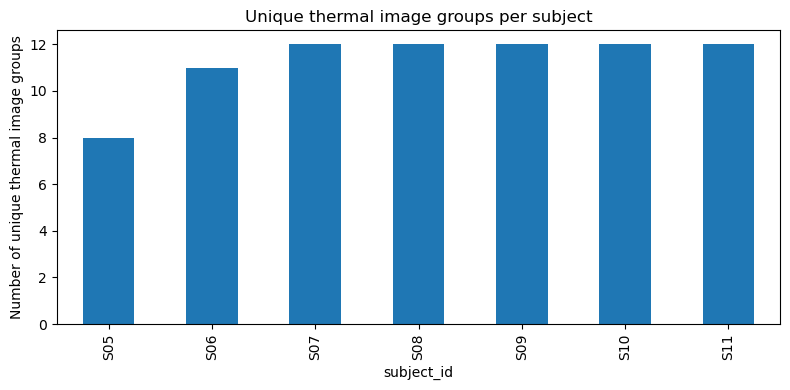

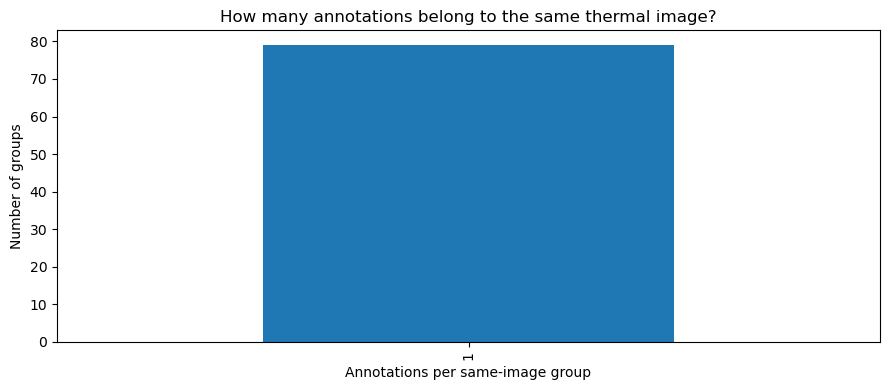

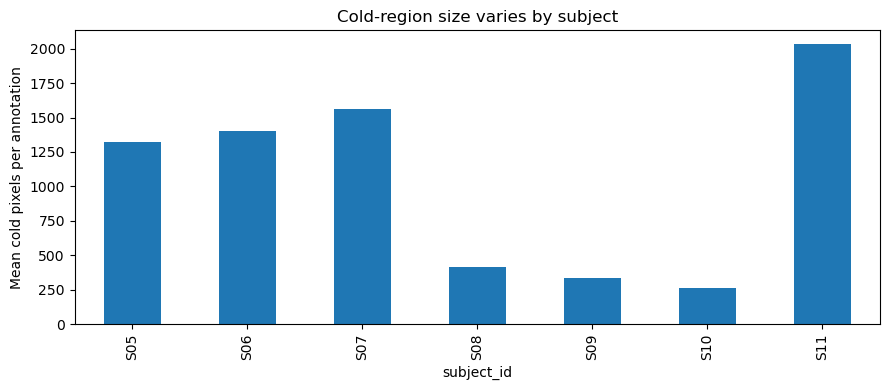

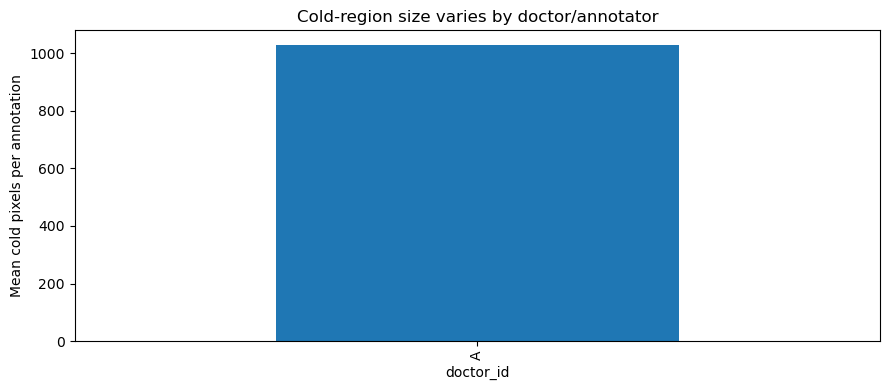

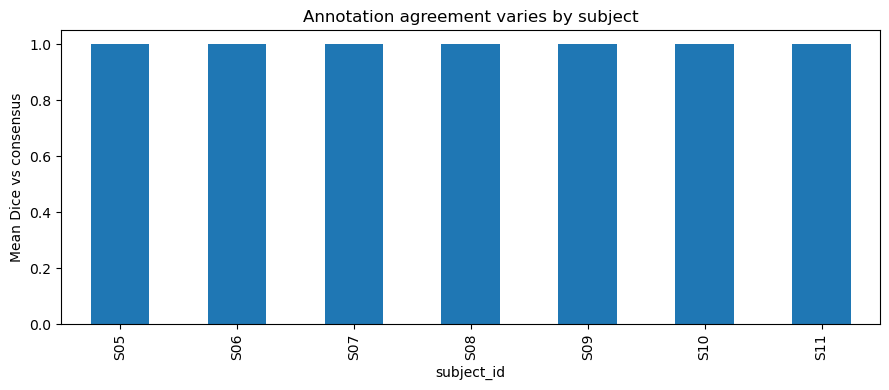

Saved slide figures to: /home/rafsan/Documents/GitHub/Cool_GANs/THERMO_DATASET_AUDIT/figures


In [23]:
# ============================================================
# SECTION 08 — SLIDE FIGURES: DATASET STRUCTURE + PIXEL COUNTS
# ============================================================

plt.figure(figsize=(8, 4))
case_table.groupby("subject_id")["audit_case_id"].nunique().sort_index().plot(kind="bar")
plt.ylabel("Number of unique thermal image groups")
plt.title("Unique thermal image groups per subject")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_01_cases_per_subject.png", dpi=200)
plt.show()

plt.figure(figsize=(9, 4))
case_table["n_annotations"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Annotations per same-image group")
plt.ylabel("Number of groups")
plt.title("How many annotations belong to the same thermal image?")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_02_annotations_per_same_image.png", dpi=200)
plt.show()

plt.figure(figsize=(9, 4))
pixel_df.groupby("subject_id")["cold_pixels"].mean().sort_index().plot(kind="bar")
plt.ylabel("Mean cold pixels per annotation")
plt.title("Cold-region size varies by subject")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_03_mean_cold_pixels_by_subject.png", dpi=200)
plt.show()

plt.figure(figsize=(9, 4))
pixel_df.groupby("doctor_id")["cold_pixels"].mean().sort_index().plot(kind="bar")
plt.ylabel("Mean cold pixels per annotation")
plt.title("Cold-region size varies by doctor/annotator")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_04_mean_cold_pixels_by_doctor.png", dpi=200)
plt.show()

if len(agreement_df) > 0:
    plt.figure(figsize=(9, 4))
    agreement_df.groupby("subject_id")["cold_dice_vs_consensus_0p5"].mean().sort_index().plot(kind="bar")
    plt.ylabel("Mean Dice vs consensus")
    plt.title("Annotation agreement varies by subject")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig_05_agreement_by_subject.png", dpi=200)
    plt.show()

print("Saved slide figures to:", FIG_DIR.resolve())

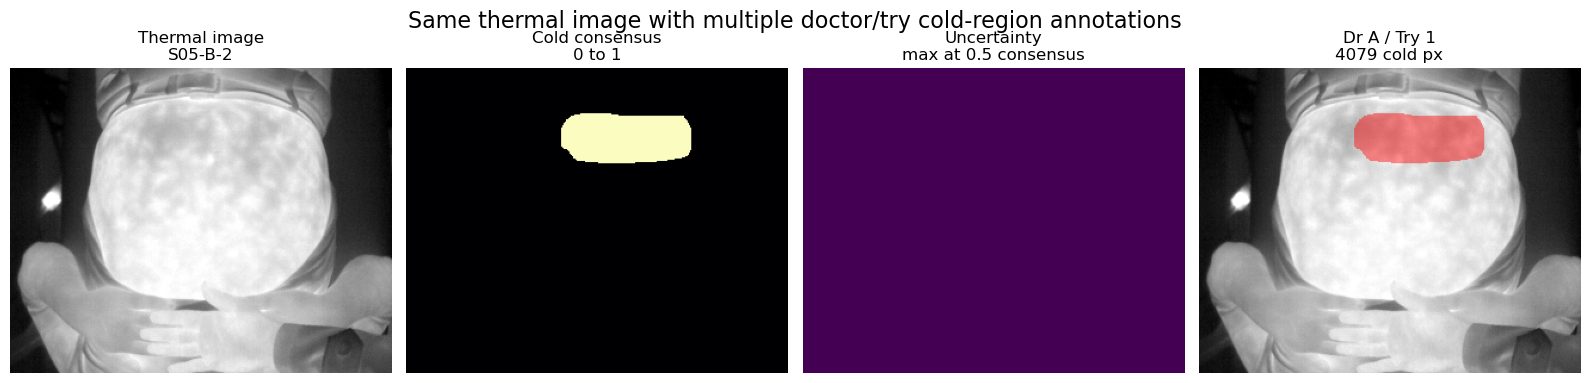

Saved: THERMO_DATASET_AUDIT/figures/08_same_image_12_mask_visualization.png


PosixPath('THERMO_DATASET_AUDIT/figures/08_same_image_12_mask_visualization.png')

In [25]:
# ============================================================
# SECTION 09 — VISUALIZATION: SAME IMAGE WITH 12 ANNOTATIONS
# Output: 08_same_image_12_mask_visualization.png
# ============================================================

def select_case_with_many_annotations():
    tmp = case_table.sort_values(["n_annotations"], ascending=False)
    if len(tmp) == 0:
        return None
    return tmp.iloc[0]["audit_case_id"]


def visualize_same_image_annotations(audit_case_id=None, max_annotations=12):
    if audit_case_id is None:
        audit_case_id = select_case_with_many_annotations()
    if audit_case_id is None:
        print("No case found")
        return None

    g = pair_df[pair_df["audit_case_id"] == audit_case_id].copy()
    g = g.copy()

    g["_doctor_sort"] = g["doctor_id"].apply(natural_sort_string)
    g["_try_sort"] = g["doctor_try"].apply(lambda x: int(x) if str(x).isdigit() else 999)
    g["_mask_sort"] = g["mask_name"].apply(natural_sort_string)

    g = (
        g.sort_values(["_doctor_sort", "_try_sort", "_mask_sort"])
        .drop(columns=["_doctor_sort", "_try_sort", "_mask_sort"])
        .reset_index(drop=True)
    )
    g = g.head(max_annotations)

    img = load_gray(g["image_path"].iloc[0])

    masks = []
    titles = []
    for _, r in g.iterrows():
        mask = load_gray(r["mask_path"])
        _, cold = mask_to_body_cold(mask)
        masks.append(cold)
        titles.append(f"Dr {r['doctor_id']} / Try {int(r['doctor_try'])}\n{int(cold.sum())} cold px")

    cold_stack = np.stack([m.astype(np.float32) for m in masks], axis=0)
    consensus = cold_stack.mean(axis=0)
    uncertainty = consensus * (1 - consensus)

    n = len(masks)
    ncols = 4
    nrows = int(math.ceil((n + 3) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    axes[0].imshow(normalize01(img), cmap="gray")
    axes[0].set_title(f"Thermal image\n{audit_case_id}")
    axes[0].axis("off")

    axes[1].imshow(consensus, cmap="magma", vmin=0, vmax=1)
    axes[1].set_title("Cold consensus\n0 to 1")
    axes[1].axis("off")

    axes[2].imshow(uncertainty, cmap="viridis", vmin=0, vmax=0.25)
    axes[2].set_title("Uncertainty\nmax at 0.5 consensus")
    axes[2].axis("off")

    for i, (mask, title) in enumerate(zip(masks, titles), start=3):
        axes[i].imshow(make_overlay(img, mask, color=(1, 0, 0), alpha=0.45))
        axes[i].set_title(title)
        axes[i].axis("off")

    for ax in axes[n+3:]:
        ax.axis("off")

    plt.suptitle("Same thermal image with multiple doctor/try cold-region annotations", fontsize=16)
    plt.tight_layout()

    save_path = FIG_DIR / "08_same_image_12_mask_visualization.png"
    plt.savefig(save_path, dpi=200)
    plt.show()
    print("Saved:", save_path)
    return save_path

visualize_same_image_annotations()

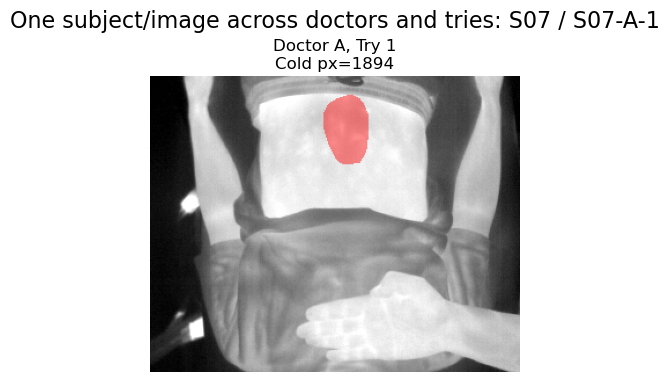

Saved: THERMO_DATASET_AUDIT/figures/fig_06_subject_S07_across_doctors.png


PosixPath('THERMO_DATASET_AUDIT/figures/fig_06_subject_S07_across_doctors.png')

In [28]:
# ============================================================
# SECTION 10 — VISUALIZATION: ONE SUBJECT ACROSS DOCTORS
# ============================================================


def sort_annotation_df(g):
    g = g.copy()

    g["_doctor_sort"] = g["doctor_id"].apply(natural_sort_string)
    g["_try_sort"] = g["doctor_try"].apply(lambda x: int(x) if str(x).isdigit() else 999)
    g["_mask_sort"] = g["mask_name"].apply(natural_sort_string)

    g = (
        g.sort_values(["_doctor_sort", "_try_sort", "_mask_sort"])
        .drop(columns=["_doctor_sort", "_try_sort", "_mask_sort"])
        .reset_index(drop=True)
    )

    return g



def visualize_subject_across_doctors(subject_id=None):
    if subject_id is None:
        # choose subject with most annotations
        subject_id = pair_df["subject_id"].value_counts().index[0]

    sub = pair_df[pair_df["subject_id"] == subject_id].copy()
    if len(sub) == 0:
        print("No data for subject", subject_id)
        return None

    # choose one same-image group with maximum annotations for this subject
    audit_case_id = sub["audit_case_id"].value_counts().index[0]
    g = pair_df[pair_df["audit_case_id"] == audit_case_id].copy()
    g = sort_annotation_df(g)

    img = load_gray(g["image_path"].iloc[0])
    doctors = sorted(g["doctor_id"].unique(), key=natural_sort_string)
    tries = sorted(g["doctor_try"].unique())

    fig, axes = plt.subplots(len(doctors), len(tries), figsize=(4 * len(tries), 4 * len(doctors)))
    if len(doctors) == 1:
        axes = np.array([axes])
    if len(tries) == 1:
        axes = axes[:, None]

    for i, d in enumerate(doctors):
        for j, t in enumerate(tries):
            ax = axes[i, j]
            row = g[(g["doctor_id"] == d) & (g["doctor_try"] == t)]
            if len(row) == 0:
                ax.axis("off")
                continue
            r = row.iloc[0]
            mask = load_gray(r["mask_path"])
            _, cold = mask_to_body_cold(mask)
            ax.imshow(make_overlay(img, cold, color=(1, 0, 0), alpha=0.45))
            ax.set_title(f"Doctor {d}, Try {t}\nCold px={int(cold.sum())}")
            ax.axis("off")

    plt.suptitle(f"One subject/image across doctors and tries: {subject_id} / {audit_case_id}", fontsize=16)
    plt.tight_layout()
    save_path = FIG_DIR / f"fig_06_subject_{subject_id}_across_doctors.png"
    plt.savefig(save_path, dpi=200)
    plt.show()
    print("Saved:", save_path)
    return save_path

visualize_subject_across_doctors()

In [29]:
# ============================================================
# SECTION 11 — VISUALIZATION: ONE DOCTOR ACROSS PATIENTS
# ============================================================

def visualize_one_doctor_across_patients(doctor_id=None, max_cases=12):
    if doctor_id is None:
        doctor_id = pair_df["doctor_id"].value_counts().index[0]

    sub = pair_df[pair_df["doctor_id"] == doctor_id].copy()
    if len(sub) == 0:
        print("No data for doctor", doctor_id)
        return None

    # take first try per audit case to avoid too much repetition
    sub = sub.sort_values(["subject_id", "audit_case_id", "doctor_try"], key=lambda s: s.map(natural_key) if s.dtype == object else s)
    sub = sub.groupby("audit_case_id").head(1).head(max_cases)

    n = len(sub)
    ncols = 4
    nrows = int(math.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, r) in zip(axes, sub.iterrows()):
        img = load_gray(r["image_path"])
        mask = load_gray(r["mask_path"])
        _, cold = mask_to_body_cold(mask)
        ax.imshow(make_overlay(img, cold, color=(1, 0, 0), alpha=0.45))
        ax.set_title(f"{r['subject_id']} / {r['parsed_case_id']}\nTry {int(r['doctor_try'])}, cold={int(cold.sum())}")
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.suptitle(f"Doctor {doctor_id}: cold annotations across patients/images", fontsize=16)
    plt.tight_layout()
    save_path = FIG_DIR / f"fig_07_doctor_{doctor_id}_across_patients.png"
    plt.savefig(save_path, dpi=200)
    plt.show()
    print("Saved:", save_path)
    return save_path

visualize_one_doctor_across_patients()

TypeError: unhashable type: 'list'

In [ ]:
# ============================================================
# SECTION 12 — VISUALIZATION: ONE SUBJECT + ONE DOCTOR ACROSS 3 TRIES
# ============================================================

def visualize_single_subject_single_doctor_tries(subject_id=None, doctor_id=None):
    candidates = (
        pair_df.groupby(["subject_id", "doctor_id", "audit_case_id"])
        .size()
        .reset_index(name="n")
        .sort_values("n", ascending=False)
    )

    if subject_id is None or doctor_id is None:
        best = candidates.iloc[0]
        subject_id = best["subject_id"]
        doctor_id = best["doctor_id"]
        audit_case_id = best["audit_case_id"]
    else:
        subcand = candidates[(candidates["subject_id"] == subject_id) & (candidates["doctor_id"] == doctor_id)]
        if len(subcand) == 0:
            print("No candidate found")
            return None
        audit_case_id = subcand.iloc[0]["audit_case_id"]

    g = pair_df[(pair_df["subject_id"] == subject_id) & (pair_df["doctor_id"] == doctor_id) & (pair_df["audit_case_id"] == audit_case_id)].copy()
    g = g.sort_values("doctor_try")

    if len(g) == 0:
        print("No rows")
        return None

    img = load_gray(g["image_path"].iloc[0])

    n = len(g)
    fig, axes = plt.subplots(1, n + 1, figsize=(4 * (n + 1), 4))

    axes[0].imshow(normalize01(img), cmap="gray")
    axes[0].set_title(f"Thermal image\n{subject_id} / {audit_case_id}")
    axes[0].axis("off")

    masks = []
    for ax, (_, r) in zip(axes[1:], g.iterrows()):
        mask = load_gray(r["mask_path"])
        _, cold = mask_to_body_cold(mask)
        masks.append(cold)
        ax.imshow(make_overlay(img, cold, color=(1, 0, 0), alpha=0.45))
        ax.set_title(f"Doctor {doctor_id}\nTry {int(r['doctor_try'])}\nCold px={int(cold.sum())}")
        ax.axis("off")

    plt.suptitle(f"Same doctor repeated decision on same subject/image", fontsize=16)
    plt.tight_layout()
    save_path = FIG_DIR / f"fig_08_subject_{subject_id}_doctor_{doctor_id}_tries.png"
    plt.savefig(save_path, dpi=200)
    plt.show()
    print("Saved:", save_path)

    if len(masks) >= 2:
        print("Pairwise Dice between tries:")
        for i, j in itertools.combinations(range(len(masks)), 2):
            print(f"Try {i+1} vs Try {j+1}: Dice={dice_bool(masks[i], masks[j]):.4f}")

    return save_path

visualize_single_subject_single_doctor_tries()

In [ ]:
# ============================================================
# SECTION 13 — VISUALIZATION: PROBLEM CASE EXAMPLES
# ============================================================

def visualize_problem_cases(max_cases=8):
    if len(problem_df) == 0:
        print("No problem cases found")
        return None

    cases = problem_df.head(max_cases)["audit_case_id"].tolist()
    n = len(cases)
    fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))
    if n == 1:
        axes = axes[None, :]

    for row_idx, audit_case_id in enumerate(cases):
        g = pair_df[pair_df["audit_case_id"] == audit_case_id].copy()
        g = g.sort_values(["doctor_id", "doctor_try", "mask_name"], key=lambda s: s.map(natural_key) if s.dtype == object else s)
        r = g.iloc[0]
        img = load_gray(r["image_path"])
        mask = load_gray(r["mask_path"])
        body, cold = mask_to_body_cold(mask)

        # consensus if exists
        cons_path = consensus_index_df[consensus_index_df["audit_case_id"] == audit_case_id]["cache_path"]
        if len(cons_path) > 0:
            cc = np.load(cons_path.iloc[0])
            consensus = cc["cold_consensus"]
            unc = cc["cold_uncertainty"]
        else:
            consensus = cold.astype(np.float32)
            unc = np.zeros_like(consensus)

        flag_text = problem_df[problem_df["audit_case_id"] == audit_case_id]["problem_flags"].iloc[0]

        axes[row_idx, 0].imshow(normalize01(img), cmap="gray")
        axes[row_idx, 0].set_title(f"Thermal\n{audit_case_id}")
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(make_overlay(img, body, color=(0, 1, 0), alpha=0.35))
        axes[row_idx, 1].set_title(f"Body mask\npx={int(body.sum())}")
        axes[row_idx, 1].axis("off")

        axes[row_idx, 2].imshow(make_overlay(img, cold, color=(1, 0, 0), alpha=0.45))
        axes[row_idx, 2].set_title(f"Cold mask\npx={int(cold.sum())}")
        axes[row_idx, 2].axis("off")

        axes[row_idx, 3].imshow(consensus, cmap="magma", vmin=0, vmax=1)
        axes[row_idx, 3].set_title("Consensus cold\n" + flag_text[:60])
        axes[row_idx, 3].axis("off")

    plt.suptitle("Problem-case examples: empty masks, abnormal cold size, low agreement, or pairing issues", fontsize=16)
    plt.tight_layout()
    save_path = FIG_DIR / "fig_09_problem_case_examples.png"
    plt.savefig(save_path, dpi=200)
    plt.show()
    print("Saved:", save_path)
    return save_path

visualize_problem_cases()

In [ ]:
# ============================================================
# SECTION 14 — FINAL AUDIT SUMMARY FOR SLIDES
# Output: 10_audit_summary_for_slides.csv
# ============================================================

summary_rows = []
summary_rows.append({"item": "n_image_files", "value": len(image_paths)})
summary_rows.append({"item": "n_mask_files", "value": len(mask_paths)})
summary_rows.append({"item": "n_unique_image_md5", "value": img_inv["md5"].nunique()})
summary_rows.append({"item": "n_unique_mask_md5", "value": mask_inv["md5"].nunique()})
summary_rows.append({"item": "n_subjects", "value": pair_df["subject_id"].nunique()})
summary_rows.append({"item": "n_audit_cases_same_image_groups", "value": pair_df["audit_case_id"].nunique()})
summary_rows.append({"item": "n_cases_with_expected_12_annotations", "value": int(case_table["expected_12_annotations"].sum())})
summary_rows.append({"item": "mean_annotations_per_same_image", "value": float(case_table["n_annotations"].mean())})
summary_rows.append({"item": "mean_cold_pixels_per_annotation", "value": float(pixel_df["cold_pixels"].mean())})
summary_rows.append({"item": "median_cold_pixels_per_annotation", "value": float(pixel_df["cold_pixels"].median())})
summary_rows.append({"item": "mean_body_pixels_per_annotation", "value": float(pixel_df["body_pixels"].mean())})
summary_rows.append({"item": "n_problem_cases", "value": len(problem_df)})

if len(agreement_df) > 0:
    summary_rows.append({"item": "mean_pairwise_cold_dice", "value": float(consensus_index_df["mean_pairwise_cold_dice"].mean())})
    summary_rows.append({"item": "median_pairwise_cold_dice", "value": float(consensus_index_df["mean_pairwise_cold_dice"].median())})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(CSV_DIR / "10_audit_summary_for_slides.csv", index=False)

display(summary_df)

print("\nAll audit CSVs saved in:", CSV_DIR.resolve())
print("All slide figures saved in:", FIG_DIR.resolve())